In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180,
                     'font.family': 'DejaVu Sans', 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
FIG = OUT / 'figures'
FIG.mkdir(exist_ok=True)
BILLION = 1e9
ALPHA = 0.05
YEARS = [1400, 1401, 1402, 1403]
COLUMNS = ['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
           'created_at_month', 'price_mode', 'price_value', 'land_size',
           'building_size', 'regular_person_capacity', 'rooms_count',
           'location_latitude', 'location_longitude', 'has_business_deed',
           'deed_type', 'construction_year']
candidates = [Path('data/Divar_selected.csv.gz'), Path('Divar.csv'), Path('data/Divar.csv')]
DATA = next((p for p in candidates if p.exists()), None)
if DATA is None:
    raise FileNotFoundError('Extract the ZIP package first, or place Divar.csv beside the notebook.')
raw = pd.read_csv(DATA, usecols=COLUMNS, dtype=str)
print(f'Rows: {len(raw):,}; selected columns: {len(raw.columns)}')
print({'pandas': pd.__version__, 'numpy': np.__version__,
       'scipy': scipy.__version__, 'matplotlib': matplotlib.__version__})
display(raw.groupby('cat2_slug', dropna=False).size().rename('rows').to_frame())


Rows: 1,000,000; selected columns: 16
{'pandas': '2.2.3', 'numpy': '2.3.5', 'scipy': '1.17.0', 'matplotlib': '3.10.8'}


,rows
cat2_slug,
commercial-rent,76567
commercial-sell,38861
real-estate-services,19403
residential-rent,276558
residential-sell,558708
temporary-rent,29903


## آماده‌سازی مشترک و تعریف جامعه تحلیل

- قیمت فروش فقط در دو دسته `residential-sell` و `commercial-sell` استفاده می‌شود؛ اجاره، اجاره موقت و خدمات/پیش‌فروش با آن مخلوط نمی‌شوند.
- قیمت ناموجود، غیرعددی، نامتناهی و صفر از تحلیل قیمت فروش کنار گذاشته می‌شود. قیمت بزرگ صرفاً به دلیل بزرگی از پاسخ اصلی حذف نمی‌شود.
- مقادیر ناموجود با صفر یا میانگین جایگزین نمی‌شوند. به‌ویژه سند نامشخص به معنای «بدون سند» نیست.
- تعداد اتاق‌ها به ۰ تا ۵ تبدیل می‌شود. «پنج یا بیشتر» در داده یک دسته سقف‌گذاری‌شده است؛ عدد ۵ تعداد دقیق اتاق‌های همه این موارد نیست.
- هر ردیف یک آگهی است. تطابق چند ستون بین دو آگهی، اثبات تکراری بودن آن‌ها نیست؛ بدون شناسه واقعی ملک، حذف تکراری بر اساس این زیرمجموعه انجام نمی‌شود.
- `created_at_month` فقط ماه میلادی را نگه می‌دارد و همه روزها ۱ هستند. برای سؤال ۷، سال شمسیِ تاریخ ثبت‌شده مبناست.
  بنابراین آگهی‌های ماه مارس در سالِ روز اول مارس قرار می‌گیرند؛ تاریخ دقیق انتشار برای تفکیک قبل/بعد نوروز موجود نیست.
  اثر کنار گذاشتن ماه مارس جداگانه بررسی می‌شود.


In [2]:
df = raw.copy()
NUMERIC = ['price_value', 'land_size', 'building_size', 'regular_person_capacity',
           'location_longitude', 'location_latitude']
for col in NUMERIC:
    df[col] = pd.to_numeric(df[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
room_map = {'بدون اتاق': 0, 'یک': 1, 'دو': 2, 'سه': 3, 'چهار': 4, 'پنج یا بیشتر': 5}
unmapped_rooms = sorted(set(raw['rooms_count'].dropna()) - set(room_map))
if unmapped_rooms:
    raise ValueError(f'Unmapped room categories: {unmapped_rooms}')
df['rooms_count'] = raw['rooms_count'].map(room_map)
df['business_deed'] = raw['has_business_deed'].map({'True': True, 'False': False})
for col in ['land_size', 'building_size', 'regular_person_capacity']:
    df.loc[df[col] <= 0, col] = np.nan
df.loc[~df['location_latitude'].between(-90, 90), 'location_latitude'] = np.nan
df.loc[~df['location_longitude'].between(-180, 180), 'location_longitude'] = np.nan

df['date'] = pd.to_datetime(raw['created_at_month'], errors='coerce')
boundaries = pd.to_datetime(['2021-03-21', '2022-03-21', '2023-03-21',
                             '2024-03-20', '2025-03-21'])
df['jalali_year'] = pd.cut(df['date'], bins=boundaries, labels=YEARS,
                           right=False).astype('Int64')
sale_mask = df['cat2_slug'].isin(['residential-sell', 'commercial-sell'])
price_ok = df['price_value'].notna() & (df['price_value'] > 0)
valid_sale = sale_mask & price_ok
audit = pd.DataFrame({'metric': [
    'All source rows', 'Sale-category rows', 'Positive sale prices',
    'Zero sale prices excluded', 'Missing sale prices excluded',
    'Positive prices outside sale categories excluded', 'Top-coded rooms (5+)'],
    'count': [len(df), int(sale_mask.sum()), int(valid_sale.sum()),
              int((sale_mask & df.price_value.eq(0)).sum()),
              int((sale_mask & df.price_value.isna()).sum()),
              int((~sale_mask & price_ok).sum()), int(raw.rooms_count.eq('پنج یا بیشتر').sum())]})
audit.to_csv(OUT / 'data_audit.csv', index=False)
display(audit)
print('All recorded dates have day=1:', bool(df['date'].dropna().dt.day.eq(1).all()))


All recorded dates have day=1: True


,metric,count
0,All source rows,1000000
1,Sale-category rows,597569
2,Positive sale prices,565190
3,Zero sale prices excluded,1901
4,Missing sale prices excluded,30478
5,Positive prices outside sale categories excluded,1254
6,Top-coded rooms (5+),13864


## سؤال ۷: میانگین قیمت حقیقی در سال‌های ۱۴۰۰ تا ۱۴۰۳

شاخص مورد استفاده، **شاخص کل قیمت مصرف‌کننده کل خانوارهای کشور، با سال پایه ۱۴۰۰=۱۰۰** است.
شاخص مسکن یا نرخ تورم نقطه‌به‌نقطه جایگزین CPI کل نشده است.
قیمت‌ها به قدرت خرید سال ۱۴۰۰ تبدیل می‌شوند:

$$\overline{P}^{real}_y=\overline{P}^{nominal}_y\times\frac{CPI_{1400}}{CPI_y}$$

از میانگین سالانه CPI استفاده می‌کنیم، نه شاخص اسفند. شاخص‌های ۱۴۰۰ تا ۱۴۰۲ از جدول ۷ گزارش مرکز آمار
و شاخص ۱۴۰۳ از میانگین ۱۲ مقدار ماهانه همان مجموعه با گرد کردن به یک رقم اعشار گرفته شده‌اند.
شاخص سال ۱۴۰۳ برابر **۲۷۱٫۷** است؛ **۳۱۵٫۷ شاخص اسفند است و میانگین سالانه نیست**.

منابع CPI: [گزارش فروردین ۱۴۰۳، جدول ۷، بازنشر گزارش مرکز آمار](https://khdccima.ir/wp-content/uploads/2024/10/tavarom-1-1403-1.pdf)
و [گزارش فروردین ۱۴۰۴، جدول ۷، نسخه بازنشر در Scribd](https://www.scribd.com/document/990610210/shg0401).


1403 mean of the 12 published monthly indices: 271.67499999999995


,annual_cpi
jalali_year,
1400,100
1401,145.8
1402,205.1
1403,271.7


,n,annual_cpi,nominal_mean_bn,real_mean_bn_1400,real_median_bn_1400
jalali_year,,,,,
1400,3,100,1.06667,1.06667,1.2
1401,47,145.8,19.2209,13.1831,1.64609
1402,4076,205.1,7.93854,3.87057,1.34081
1403,561063,271.7,17.5169,6.44713,1.04895


,real_mean_yoy_pct,observed_gregorian_months
jalali_year,,
1400,NaN,3
1401,"1,135.91",11
1402,-70.6399,12
1403,66.5681,12


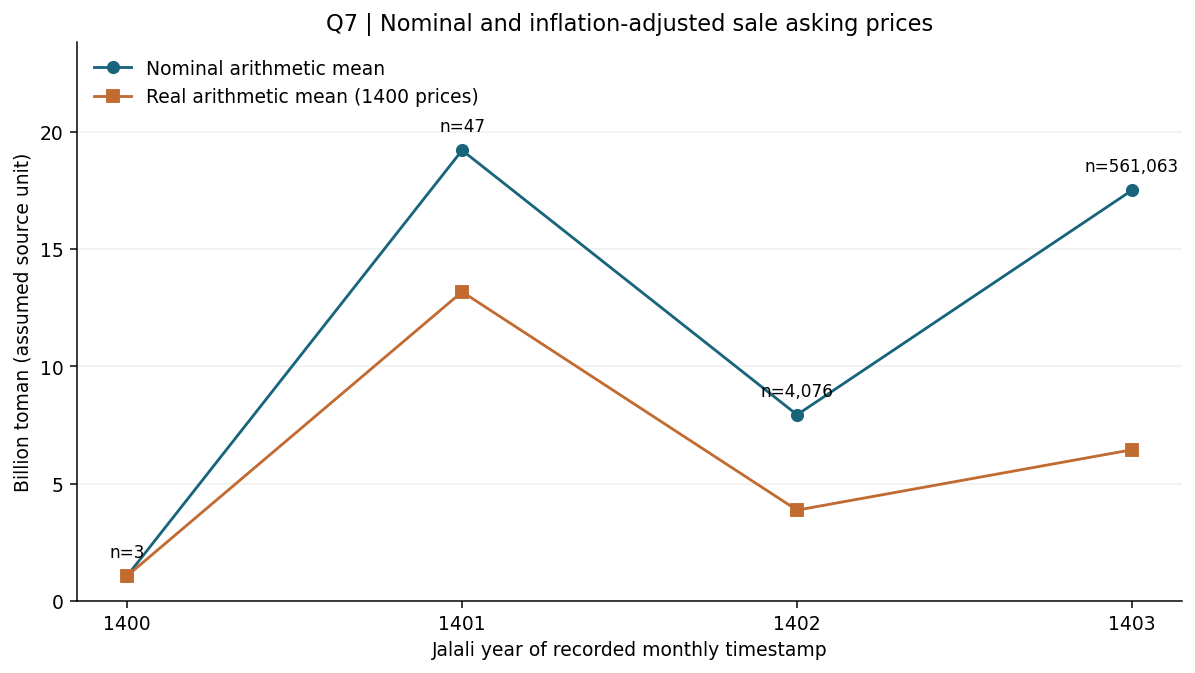

In [3]:
cpi_monthly_1403 = np.array([236.3, 243.0, 249.7, 255.2, 260.2, 264.7,
                            271.8, 279.5, 285.1, 293.4, 305.5, 315.7])
cpi = pd.Series({1400: 100.0, 1401: 145.8, 1402: 205.1,
                 1403: round(float(cpi_monthly_1403.mean()), 1)}, name='annual_cpi')
display(cpi.rename_axis('jalali_year').to_frame())
print('1403 mean of the 12 published monthly indices:', cpi_monthly_1403.mean())
cpi.rename_axis('jalali_year').to_csv(OUT / 'cpi_annual_1400_1403.csv')
pd.DataFrame({'jalali_month': range(1, 13), 'cpi_1400_base': cpi_monthly_1403}).to_csv(
    OUT / 'cpi_monthly_1403.csv', index=False)

annual_rows = df.loc[valid_sale & df['jalali_year'].notna()].copy()
annual = annual_rows.groupby('jalali_year').agg(
    n=('price_value', 'size'), nominal_mean=('price_value', 'mean'),
    nominal_median=('price_value', 'median'),
    observed_gregorian_months=('created_at_month', 'nunique')).reindex(YEARS)
annual['annual_cpi'] = cpi
annual['real_mean_1400'] = annual['nominal_mean'] * 100 / annual['annual_cpi']
annual['real_median_1400'] = annual['nominal_median'] * 100 / annual['annual_cpi']
annual['real_mean_yoy_pct'] = annual['real_mean_1400'].pct_change(fill_method=None) * 100
annual.to_csv(OUT / 'q7_annual_prices.csv')
annual_view = annual[['n', 'annual_cpi', 'nominal_mean', 'real_mean_1400', 'real_median_1400']].copy()
for col in ['nominal_mean', 'real_mean_1400', 'real_median_1400']:
    annual_view[col] /= BILLION
annual_view = annual_view.rename(columns={'nominal_mean': 'nominal_mean_bn',
                                           'real_mean_1400': 'real_mean_bn_1400',
                                           'real_median_1400': 'real_median_bn_1400'})
display(annual_view)
display(annual[['real_mean_yoy_pct', 'observed_gregorian_months']])

fig, ax = plt.subplots(figsize=(9, 5.1))
ax.plot(YEARS, annual.nominal_mean / BILLION, marker='o', color='#17647b', label='Nominal arithmetic mean')
ax.plot(YEARS, annual.real_mean_1400 / BILLION, marker='s', color='#c16b31', label='Real arithmetic mean (1400 prices)')
for year, row in annual.iterrows():
    ax.annotate(f'n={int(row["n"]):,}', (year, row['nominal_mean'] / BILLION),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)
ax.set_xticks(YEARS)
ax.set(xlabel='Jalali year of recorded monthly timestamp', ylabel='Billion toman (assumed source unit)',
       title='Q7 | Nominal and inflation-adjusted sale asking prices')
ax.set_ylim(bottom=0, top=annual.nominal_mean.max() / BILLION * 1.24)
ax.grid(axis='y', alpha=.2)
ax.legend(frameon=False, loc='upper left')
fig.tight_layout()
fig.savefig(FIG / 'q7_nominal_real.png')
plt.show()
plt.close(fig)


### بررسی حساسیت سؤال ۷

میانگین حسابی به قیمت‌های بسیار بزرگ حساس است. در کنار پاسخ اصلی، میانه حقیقی و میانگین پس از وینزور ۱٪ گزارش می‌شوند.
وینزور یعنی مقادیر کمتر از صدک ۱ یا بیشتر از صدک ۹۹ را به همان آستانه برسانیم؛ ردیف‌ها حذف نمی‌شوند.
برای مقایسه سال‌ها، آستانه مشترک از قیمت‌های اسمی تمام چهار سال محاسبه می‌شود.
این یک **تحلیل حساسیت با معیار تغییریافته** است، نه اثبات اشتباه بودن قیمت‌های خارج از آستانه و نه جایگزین مخفی میانگین اصلی.
همچنین برای حساسیت به ابهام تاریخ ماهانه، میانگین با حذف مارس محاسبه می‌شود.


Shared nominal-price winsor bounds: 111111.0 86000000000.0


,n,real_mean_1400,real_median_1400,real_winsor_mean_1400,n_without_march,real_mean_without_march
jalali_year,,,,,,
1400,3,1.06667e+09,1.2e+09,1.06667e+09,3,1.06667e+09
1401,47,1.31831e+10,1.64609e+09,1.00207e+10,41,1.39723e+10
1402,4076,3.87057e+09,1.34081e+09,3.18843e+09,2775,4.03796e+09
1403,561063,6.44713e+09,1.04895e+09,2.25407e+09,561059,6.44716e+09


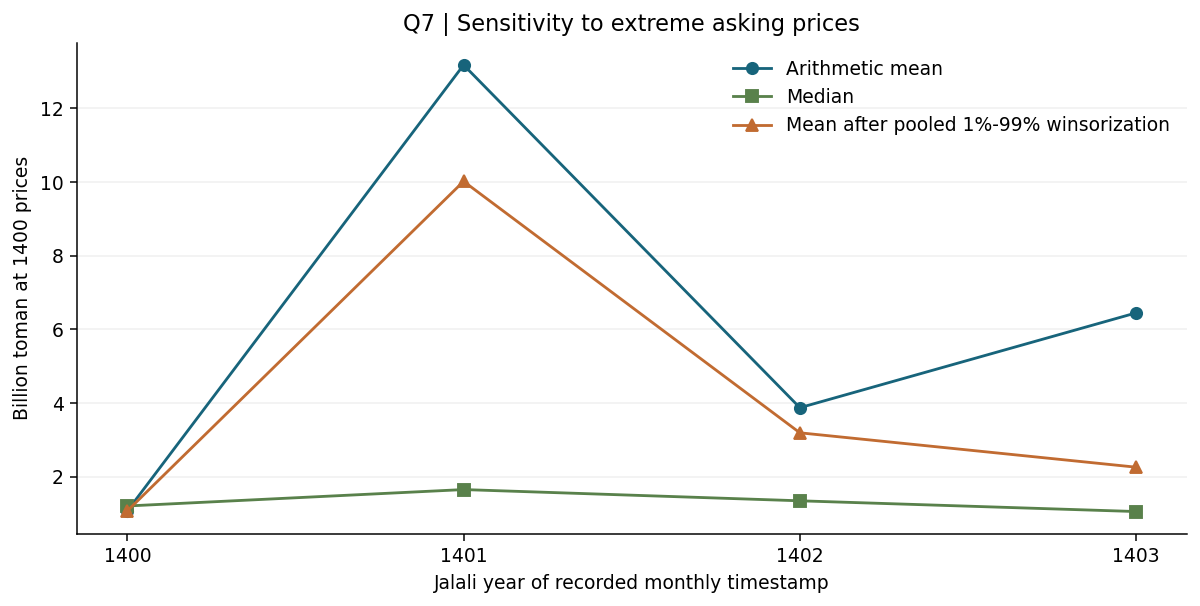

In [4]:
q7_low, q7_high = annual_rows.price_value.quantile([.01, .99])
annual_rows['winsor_price'] = annual_rows.price_value.clip(q7_low, q7_high)
q7_sensitivity = annual[['n', 'real_mean_1400', 'real_median_1400']].copy()
q7_sensitivity['real_winsor_mean_1400'] = (
    annual_rows.groupby('jalali_year').winsor_price.mean().reindex(YEARS) * 100 / cpi)
no_march = annual_rows.loc[annual_rows.date.dt.month.ne(3)]
q7_sensitivity['n_without_march'] = no_march.groupby('jalali_year').size().reindex(YEARS)
q7_sensitivity['real_mean_without_march'] = (
    no_march.groupby('jalali_year').price_value.mean().reindex(YEARS) * 100 / cpi)
q7_sensitivity.to_csv(OUT / 'q7_sensitivity.csv')
print('Shared nominal-price winsor bounds:', q7_low, q7_high)
display(q7_sensitivity)
annual_rows.groupby(['jalali_year', 'created_at_month']).size().rename('n').to_csv(
    OUT / 'q7_monthly_sample_counts.csv')

fig, ax = plt.subplots(figsize=(9, 4.6))
for col, label, marker, color in [
    ('real_mean_1400', 'Arithmetic mean', 'o', '#17647b'),
    ('real_median_1400', 'Median', 's', '#59814b'),
    ('real_winsor_mean_1400', 'Mean after pooled 1%-99% winsorization', '^', '#c16b31')]:
    ax.plot(YEARS, q7_sensitivity[col] / BILLION, label=label, marker=marker, color=color)
ax.set_xticks(YEARS)
ax.set(xlabel='Jalali year of recorded monthly timestamp', ylabel='Billion toman at 1400 prices',
       title='Q7 | Sensitivity to extreme asking prices')
ax.grid(axis='y', alpha=.2)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG / 'q7_sensitivity.png')
plt.show()
plt.close(fig)


**تفسیر سؤال ۷:** میانگین حقیقی در این نمونه از ۱۴۰۰ به ۱۴۰۱ افزایش، در ۱۴۰۲ کاهش و در ۱۴۰۳ دوباره افزایش دارد؛ روند یکنواخت نیست.
برای ۱۴۰۰ فقط ۳ آگهی و برای ۱۴۰۱ فقط ۴۷ آگهی فروش قیمت‌دار وجود دارد؛ تقریباً تمام حجم نمونه در ۱۴۰۳ است.
اختلاف بزرگ میانگین و میانه و تغییر نتیجه با کنترل مقادیر افراطی، حساسیت به کیفیت داده را نشان می‌دهد.
از ۱۴۰۲ به ۱۴۰۳، برخلاف میانگین خام، میانه حقیقی و میانگین حقیقی وینزورشده کاهش پیدا می‌کنند.
بنابراین این نمودار روند **میانگین آگهی‌های همین فایل** را نشان می‌دهد و مبنای کافی برای ادعای رشد واقعی کل بازار مسکن ایران نیست.
ترکیب شهر، نوع ملک، متراژ و ماه‌های مشاهده‌شده ثابت نگه داشته نشده است و مبلغ آگهی نیز قیمت معامله قطعی نیست.


## سؤال ۸: ماتریس همبستگی

هفت متغیر در ماتریس وجود دارد: مبلغ قیمت، متراژ زمین، زیربنا، ظرفیت معمول نفرات، تعداد اتاق، طول و عرض جغرافیایی.
«ظرفیت نفرات» به ستون `regular_person_capacity` نگاشت شده است؛ ظرفیت اضافه به آن جمع نشده است.
ماتریس اصلی **Pearson** است و **Spearman** برای بررسی حساسیت به مقادیر پرت و روابط یکنواخت ارائه می‌شود.

برای هر جفت متغیر فقط ردیف‌هایی به کار می‌روند که همان دو مقدار موجود باشند (pairwise complete observations).
شرط حداقل ۳۰ مشاهده برای گزارش ضریب اعمال می‌شود؛ همه جفت‌های قابل گزارش در این داده بسیار بیشتر از این تعداد مشاهده دارند.
ظرفیت نفرات در اجاره موقت ثبت شده، ولی قیمت فروش معتبر در آگهی‌های فروش است؛ هیچ هم‌پوشانی معتبر بین این دو وجود ندارد.
بین ظرفیت نفرات و متراژ زمین نیز هم‌پوشانی وجود ندارد. این خانه‌ها **NA** هستند، نه صفر.
حذف همه ردیف‌هایی که یکی از هفت متغیرشان خالی باشد، کل نمونه را از بین می‌برد.


Pearson correlations:
Pairwise observation counts:
Rows complete across all seven variables: 0


,price_value,land_size,building_size,regular_person_capacity,rooms_count,location_longitude,location_latitude
price_value,1,-0.000415091,0.0521635,NaN,0.0140685,0.00180651,0.00314441
land_size,-0.000415091,1,0.372622,NaN,-0.00486981,0.00591247,-0.00730209
building_size,0.0521635,0.372622,1,0.0184957,-0.0117913,0.00123517,-0.0103618
regular_person_capacity,NaN,NaN,0.0184957,1,0.344266,0.0417042,-0.0462064
rooms_count,0.0140685,-0.00486981,-0.0117913,0.344266,1,0.0420181,-0.0211233
location_longitude,0.00180651,0.00591247,0.00123517,0.0417042,0.0420181,1,-0.222207
location_latitude,0.00314441,-0.00730209,-0.0103618,-0.0462064,-0.0211233,-0.222207,1


,price_value,land_size,building_size,regular_person_capacity,rooms_count,location_longitude,location_latitude
price_value,565190,120771,565157,0,454987,370153,370153
land_size,120771,186396,186396,0,186396,113566,113566
building_size,565157,186396,980394,29870,845899,644526,644526
regular_person_capacity,0,0,29870,29870,29870,19456,19456
rooms_count,454987,186396,845899,29870,845899,559319,559319
location_longitude,370153,113566,644526,19456,559319,655608,655608
location_latitude,370153,113566,644526,19456,559319,655608,655608


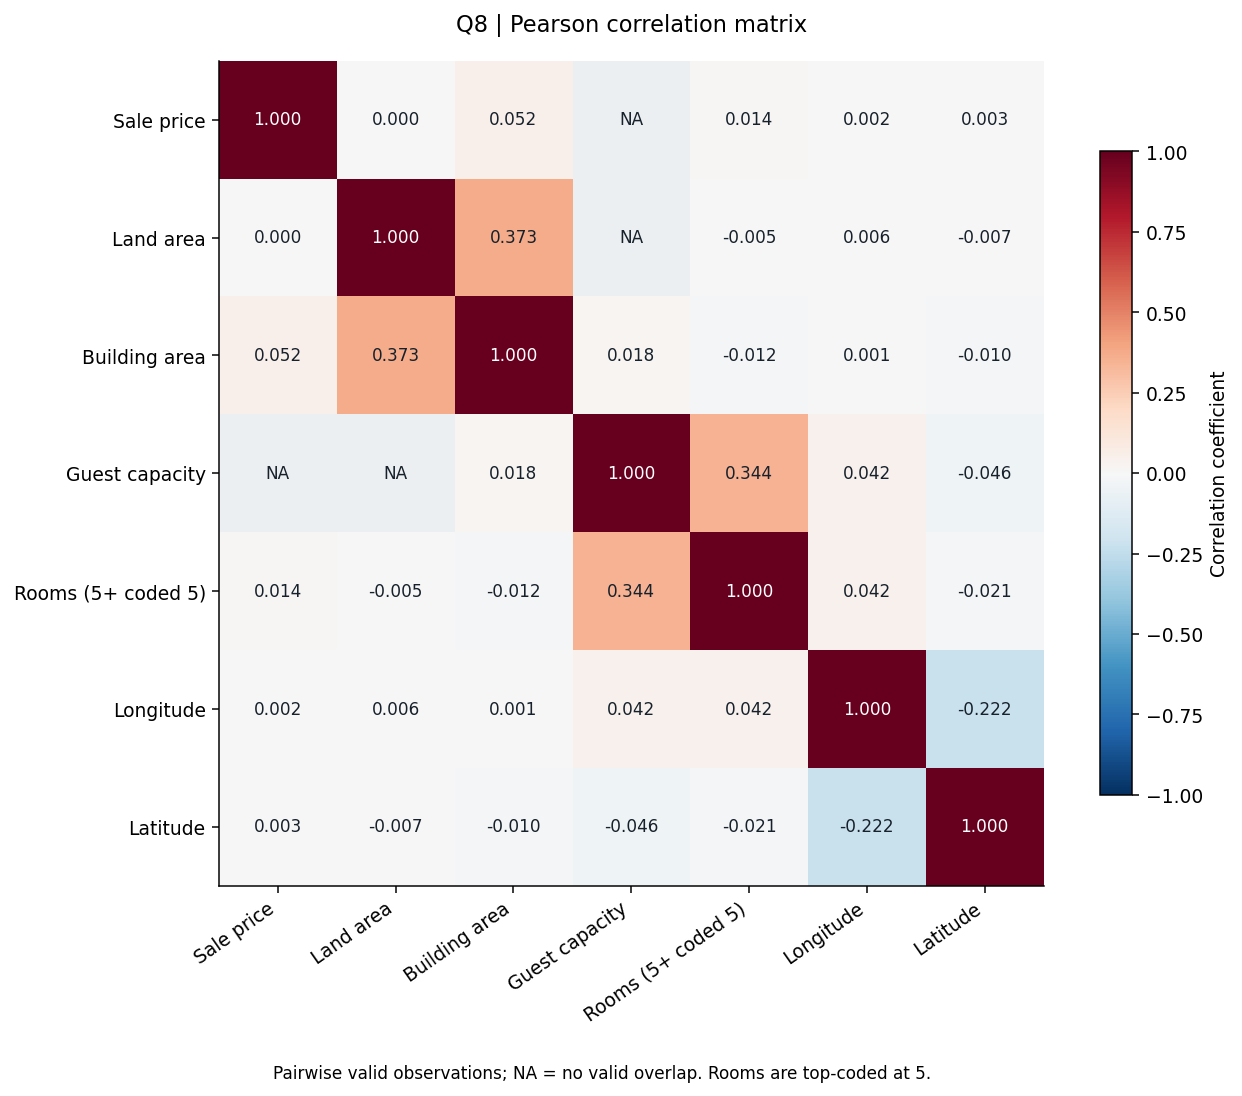

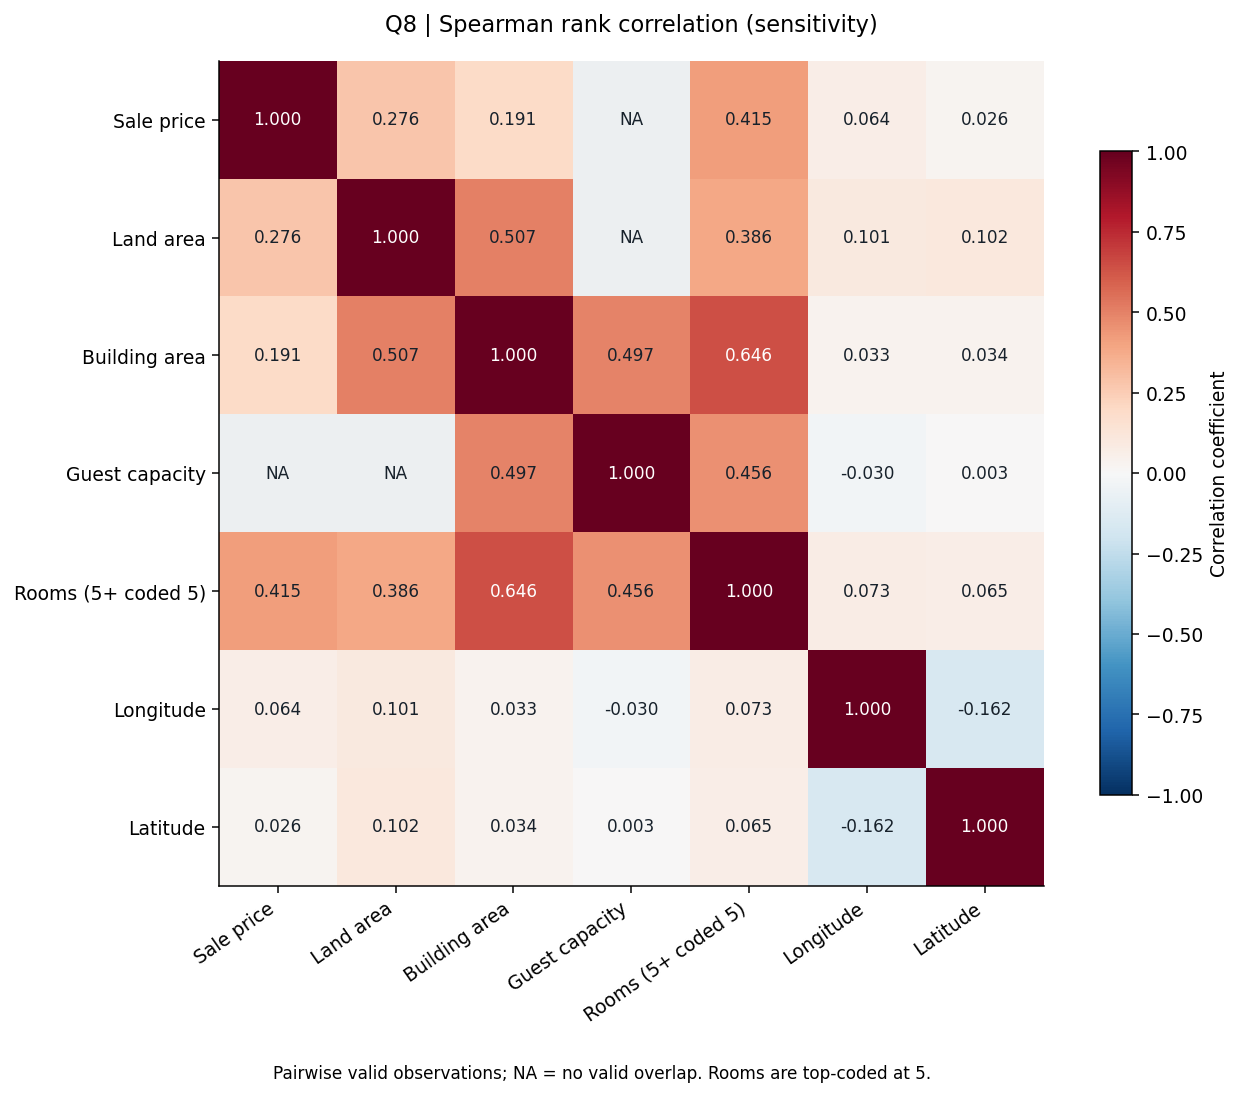

,price_value,land_size,building_size,regular_person_capacity,rooms_count,location_longitude,location_latitude
price_value,1,0.276413,0.19094,NaN,0.414664,0.063714,0.0260912
land_size,0.276413,1,0.506688,NaN,0.385752,0.100875,0.101919
building_size,0.19094,0.506688,1,0.497071,0.646287,0.033069,0.0335531
regular_person_capacity,NaN,NaN,0.497071,1,0.455709,-0.0295093,0.00286183
rooms_count,0.414664,0.385752,0.646287,0.455709,1,0.0727055,0.0646758
location_longitude,0.063714,0.100875,0.033069,-0.0295093,0.0727055,1,-0.161925
location_latitude,0.0260912,0.101919,0.0335531,0.00286183,0.0646758,-0.161925,1


In [5]:
CORR_COLS = ['price_value', 'land_size', 'building_size', 'regular_person_capacity',
             'rooms_count', 'location_longitude', 'location_latitude']
matrix_data = df[CORR_COLS].copy()
matrix_data.loc[~valid_sale, 'price_value'] = np.nan
pearson = matrix_data.corr(method='pearson', min_periods=30)
spearman = matrix_data.corr(method='spearman', min_periods=30)
observed = matrix_data.notna().astype('int64')
pair_counts = observed.T @ observed
pearson.to_csv(OUT / 'q8_pearson.csv')
spearman.to_csv(OUT / 'q8_spearman.csv')
pair_counts.to_csv(OUT / 'q8_pair_counts.csv')
matrix_data.isna().sum().rename('missing').to_csv(OUT / 'q8_missing_counts.csv')
print('Pearson correlations:')
display(pearson)
print('Pairwise observation counts:')
display(pair_counts)
print('Rows complete across all seven variables:', len(matrix_data.dropna()))

labels = ['Sale price', 'Land area', 'Building area', 'Guest capacity',
          'Rooms (5+ coded 5)', 'Longitude', 'Latitude']
def correlation_plot(matrix, title, filename):
    fig, ax = plt.subplots(figsize=(10.2, 8.2))
    cmap = plt.get_cmap('RdBu_r').copy()
    cmap.set_bad('#eceff1')
    image = ax.imshow(np.ma.masked_invalid(matrix.to_numpy()), vmin=-1, vmax=1, cmap=cmap)
    ax.set_xticks(range(7), labels, rotation=35, ha='right')
    ax.set_yticks(range(7), labels)
    for i in range(7):
        for j in range(7):
            value = matrix.iloc[i, j]
            text = 'NA' if pd.isna(value) else f'{value:.3f}'
            if text == '-0.000':
                text = '0.000'
            ax.text(j, i, text, ha='center', va='center', fontsize=9,
                    color='white' if pd.notna(value) and abs(value) > .6 else '#17212b')
    fig.colorbar(image, ax=ax, shrink=.78, label='Correlation coefficient')
    ax.set_title(title, pad=16)
    fig.text(.5, .02, 'Pairwise valid observations; NA = no valid overlap. Rooms are top-coded at 5.',
             ha='center', fontsize=9)
    fig.tight_layout(rect=[0, .05, 1, 1])
    fig.savefig(FIG / filename)
    plt.show()
    plt.close(fig)
correlation_plot(pearson, 'Q8 | Pearson correlation matrix', 'q8_pearson.png')
correlation_plot(spearman, 'Q8 | Spearman rank correlation (sensitivity)', 'q8_spearman.png')
display(spearman)


**تفسیر سؤال ۸:** در Pearson، همبستگی زمین و زیربنا حدود ۰٫۳۷۳ و همبستگی ظرفیت نفرات و تعداد اتاق حدود ۰٫۳۴۴ است.
همبستگی خام قیمت و زیربنا حدود ۰٫۰۵۲ و قیمت و تعداد اتاق حدود ۰٫۰۱۴ است؛ این اعداد به تنهایی نبود رابطه را ثابت نمی‌کنند.
در Spearman، قیمت و تعداد اتاق حدود ۰٫۴۱۵، زیربنا و تعداد اتاق حدود ۰٫۶۴۶ و زیربنا و ظرفیت نفرات حدود ۰٫۴۹۷ هستند.
اختلاف دو روش با حضور داده‌های افراطی و شکل غیرخطی رابطه سازگار است.

هر جفت ضریب ممکن است بر زیرجمعیت متفاوتی از آگهی‌ها محاسبه شده باشد؛ جدول تعداد مشاهدات برای همین منظور همراه نتیجه است.
تعداد اتاق‌ها متغیر سقف‌گذاری‌شده است. ضریب پایین قیمت با طول/عرض جغرافیایی هم به معنای بی‌اهمیت بودن مکان نیست؛
اثر شهر و محله را نمی‌توان با یک رابطه خطی سراسری با مختصات خلاصه کرد. همبستگی نیز رابطه علّی را اثبات نمی‌کند.
